In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import KFold, GroupKFold, StratifiedGroupKFold

from PIL import Image
from tqdm.auto import tqdm
tqdm.pandas()


In [21]:
DATA_ROOT = 'csiro-biomass/'

In [22]:
train_df = pd.read_csv(f'{DATA_ROOT}train.csv')
train_df.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.275


In [23]:
train_df[['sample_id_prefix', 'sample_id_suffix']] = train_df.sample_id.str.split('__', expand=True)

In [24]:
cols = ['sample_id_prefix', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']

agg_train_df = (
    train_df
    .pivot_table(index=cols, columns='target_name', values='target', aggfunc='first')
    .reset_index()
)
agg_train_df.columns.name = None

agg_train_df['image'] = agg_train_df.image_path.progress_apply(
    lambda path: Image.open(DATA_ROOT + path).convert('RGB')
)
agg_train_df.head()

  0%|          | 0/357 [00:00<?, ?it/s]

,sample_id_prefix,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,image
0,ID1011485656,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,0.0,31.9984,16.2751,48.2735,16.275,<PIL.Image.Image image mode=RGB size=2000x1000...
1,ID1012260530,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,0.0,0.0,7.6,7.6,7.6C,<PIL.Image.Image image mode=RGB size=2000x1000...
2,ID1025234388,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,6.05,0.0,0.0,6.05,6.05,<PIL.Image.Image image mode=RGB size=2000x1000...
3,ID1028611175,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,0.0,30.9703,24.2376,55.2079,24.2376,<PIL.Image.Image image mode=RGB size=2000x1000...
4,ID1035947949,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,0.4343,23.2239,10.5261,34.1844,10.9605,<PIL.Image.Image image mode=RGB size=2000x1000...


In [30]:
agg_train_df[['Dry_Green_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Dead_g', 'Dry_Total_g']].dtypes


Dry_Green_g     object
Dry_Clover_g    object
GDM_g           object
Dry_Dead_g      object
Dry_Total_g     object
dtype: object

In [31]:
target_cols = ['Dry_Green_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Dead_g', 'Dry_Total_g']
agg_train_df[target_cols] = agg_train_df[target_cols].apply(pd.to_numeric, errors='coerce')
agg_train_df[target_cols].dtypes

Dry_Green_g     float64
Dry_Clover_g    float64
GDM_g           float64
Dry_Dead_g      float64
Dry_Total_g     float64
dtype: object

In [25]:
agg_train_df['image_size'] = agg_train_df.image.apply(lambda x: x.size)
agg_train_df['image_size'].value_counts()

image_size
(2000, 1000)    357
Name: count, dtype: int64

These are data integrity checks — verifying that certain columns are derived from others (i.e., the math adds up).

Check 1:


```Dry_Green_g + Dry_Clover_g ≈ GDM_g```
Checks what fraction of rows satisfy this. If the result is 1.0, then GDM_g (Green Dry Matter) is always the sum of its green and clover components.

Check 2:


```GDM_g + Dry_Dead_g ≈ Dry_Total_g```
Checks what fraction of rows satisfy this. Verifies that total dry matter = green dry matter + dead dry matter.

atol=1e-04 allows a tiny tolerance (±0.0001g) to account for floating point rounding. .mean() converts the boolean array to a proportion — 1.0 means 100% of rows pass.

The implied data hierarchy:
```
Dry_Total_g
├── GDM_g  (Green Dry Matter)
│   ├── Dry_Green_g
│   └── Dry_Clover_g
└── Dry_Dead_g
```
If both checks return 1.0, those relationships hold perfectly across the dataset. If not (e.g. 0.97), ~3% of rows have inconsistencies worth investigating.

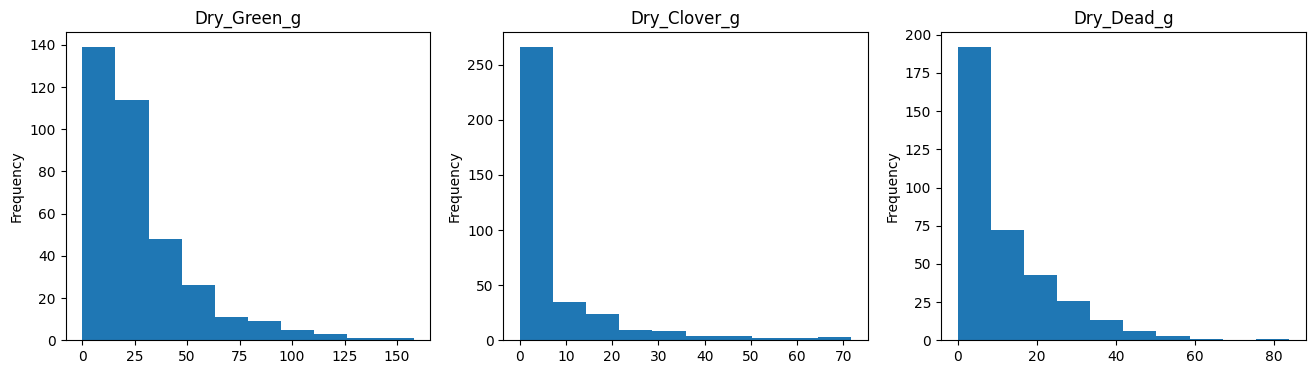

In [34]:
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
agg_train_df.Dry_Green_g.plot(kind='hist')
_ = plt.title('Dry_Green_g')

plt.subplot(1, 3, 2)
agg_train_df.Dry_Clover_g.plot(kind='hist')
_ = plt.title('Dry_Clover_g')

plt.subplot(1, 3, 3)
agg_train_df.Dry_Dead_g.plot(kind='hist')
_ = plt.title('Dry_Dead_g')

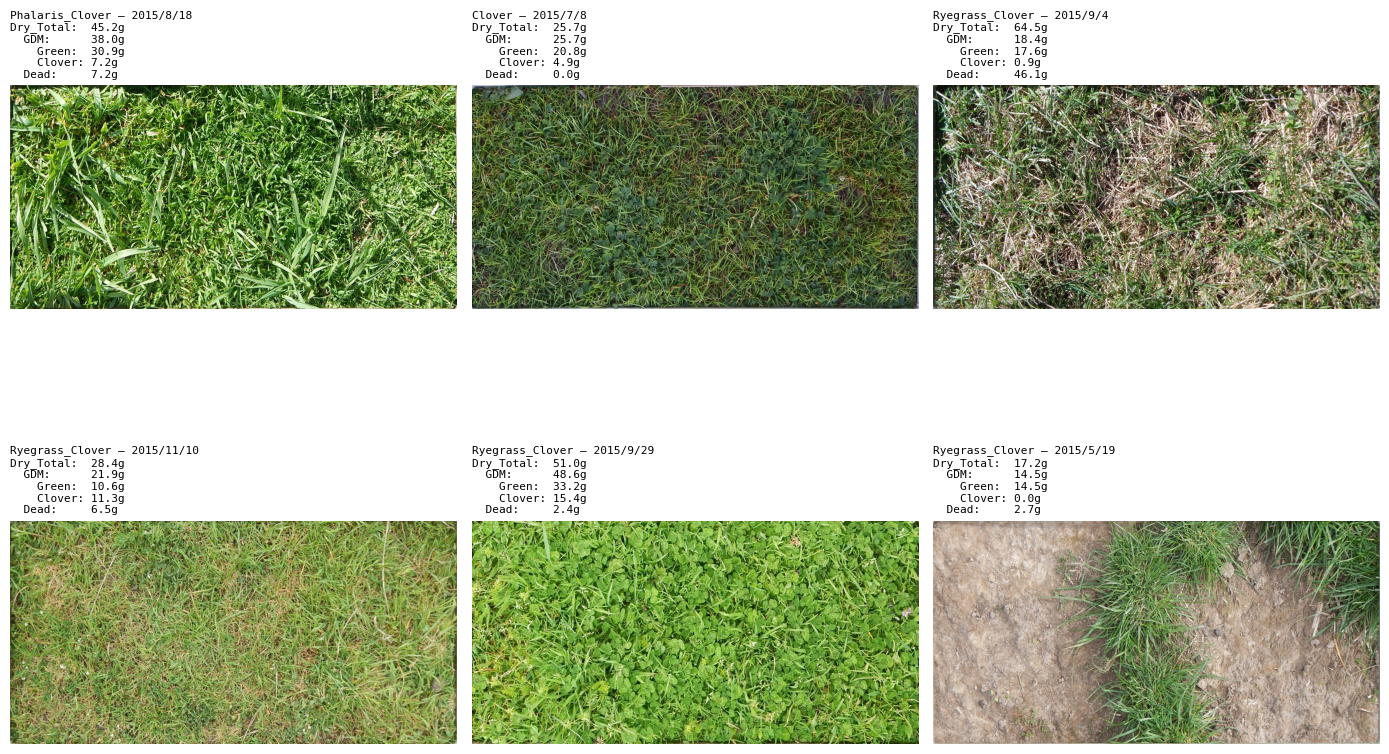

In [38]:
import matplotlib.pyplot as plt

n = 6
samples = agg_train_df.sample(n)

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    ax.imshow(row['image'])
    ax.axis('off')

    title = (
        f"{row['Species']} — {row['Sampling_Date']}\n"
        f"Dry_Total:  {row['Dry_Total_g']:.1f}g\n"
        f"  GDM:      {row['GDM_g']:.1f}g\n"
        f"    Green:  {row['Dry_Green_g']:.1f}g\n"
        f"    Clover: {row['Dry_Clover_g']:.1f}g\n"
        f"  Dead:     {row['Dry_Dead_g']:.1f}g"
    )
    ax.set_title(title, fontsize=8, family='monospace', loc='left')

plt.tight_layout()
plt.show()


# Dataloader

In [57]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class RegressionDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        image = item.image

        if self.transform:
            image = self.transform(image)

        targets = [item['Dry_Green_g'], item['Dry_Clover_g'], item['Dry_Dead_g']]
        return image, targets


def create_dataloader(data, target_image_size=(256, 256), batch_size=32, shuffle=True, aug=True):    
    if aug:
        transform = transforms.Compose([
            transforms.Resize(target_image_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    else:
        transform = transforms.Compose([
            transforms.Resize(target_image_size),

            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    dataset = RegressionDataset(data, transform=transform)
    print('dataset size:', len(dataset))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)
    return dataloader

# Model

In [58]:
import timm
MODEL_NAME = 'efficientnet_b2'
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=3)   
model.pretrained_cfg

{'url': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/efficientnet_b2_ra-bcdf34b7.pth',
 'hf_hub_id': 'timm/efficientnet_b2.ra_in1k',
 'architecture': 'efficientnet_b2',
 'tag': 'ra_in1k',
 'custom_load': False,
 'input_size': (3, 256, 256),
 'test_input_size': (3, 288, 288),
 'fixed_input_size': False,
 'interpolation': 'bicubic',
 'crop_pct': 0.875,
 'test_crop_pct': 1.0,
 'crop_mode': 'center',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'num_classes': 1000,
 'pool_size': (8, 8),
 'first_conv': 'conv_stem',
 'classifier': 'classifier'}

In [59]:
TARGET_IMAGE_SIZE = model.pretrained_cfg['input_size'][1:]

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import AdamW

# ======== Weighted R² ========
def weighted_r2_score(y_true: np.ndarray, y_pred: np.ndarray):
    """
    y_true, y_pred: shape (N, 5): Green/Clover/Dead/GDM/Total
    """
    weights = np.array([0.1, 0.1, 0.1, 0.2, 0.5])
    r2_scores = []
    for i in range(5):
        y_t = y_true[:, i]
        y_p = y_pred[:, i]
        ss_res = np.sum((y_t - y_p) ** 2)
        ss_tot = np.sum((y_t - np.mean(y_t)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        r2_scores.append(r2)
    r2_scores = np.array(r2_scores)
    weighted_r2 = np.sum(r2_scores * weights) / np.sum(weights)
    return weighted_r2, r2_scores

def calc_metric(outputs, targets):
    '''
        outputs/targets: shape (N, 3): Green/Clover/Dead
    '''
    y_true = np.column_stack((
        targets,
        targets[:, :2].sum(axis=1),
        targets.sum(axis=1),
    ))
    
    y_pred = np.column_stack((
        outputs,
        outputs[:, :2].sum(axis=1),
        outputs.sum(axis=1),
    ))
    
    weighted_r2, r2_scores = weighted_r2_score(y_true, y_pred)
    return weighted_r2, r2_scores

In [61]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, targets in dataloader:
        images = images.to(device)
        targets = torch.stack(targets).T.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_outputs = []
    all_targets = []

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = torch.stack(targets).T.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

            all_outputs.append(outputs.detach().cpu())
            all_targets.append(targets.detach().cpu())

    outputs = torch.cat(all_outputs).numpy()
    targets = torch.cat(all_targets).numpy()
    
    weighted_r2, r2_scores = calc_metric(outputs, targets)

    return total_loss / len(dataloader), weighted_r2, r2_scores

In [62]:
NFOLD = 5
kfold = KFold(n_splits=NFOLD, shuffle=True, random_state=42)

agg_train_df['fold'] = None
for i, (trn_idx, val_idx) in enumerate(kfold.split(agg_train_df.index)):
    agg_train_df.loc[val_idx, 'fold'] = i

In [63]:
def train_fold(data, fold):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    
    # Hyperparameters
    batch_size = 32
    lr = 1e-3
    patience = 10
    num_epochs = 5

    # model, loss, optimizer
    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=3)
    model.to(device)

    criterion = nn.SmoothL1Loss()  # nn.MSELoss()
    optimizer = AdamW(model.parameters(), lr=lr)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=patience//2
    )
    
    # data
    train_loader = create_dataloader(data[data.fold != fold], TARGET_IMAGE_SIZE, batch_size, shuffle=True, aug=True)
    val_loader = create_dataloader(data[data.fold == fold], TARGET_IMAGE_SIZE, batch_size, shuffle=False, aug=False)

    # Training loop
    history = []
    best_score = -float('inf')
    epochs_without_improvement = 0
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, weighted_r2, r2_scores = validate(model, val_loader, criterion, device)
        
        scheduler.step(weighted_r2)

        if epoch % 10 == 0:
            print(f"Epoch [{epoch}/{num_epochs}]: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, weighted_r2: {weighted_r2:.4f}, lr: {optimizer.param_groups[0]['lr']}")
        
        history.append({
            'train_loss': train_loss,
            'val_loss': val_loss,
            'weighted_r2': weighted_r2,
            'r2_scores': r2_scores,
        })
    
        if weighted_r2 > best_score:
            best_score = weighted_r2
            epochs_without_improvement = 0
            torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_mode_fold{fold}.pth')
        
        else:
            epochs_without_improvement += 1
        
        if epochs_without_improvement >= patience:
            print(f"epoch={epoch}, {patience} 个 epoch")
            break

    print(f"\nTraining completed. Best weighted_r2: {best_score:.4f}")
    
    return history, best_score

In [64]:
OUTPUT_DIR = 'trained_models/'
if not os.path.exists(OUTPUT_DIR):
    os.mkdir(OUTPUT_DIR)

### fold=0
dataset size: 285
dataset size: 72
Epoch [0/5]: Train Loss: 11.9730, Val Loss: 11.2280, weighted_r2: -1.0691, lr: 0.001

Training completed. Best weighted_r2: 0.6398


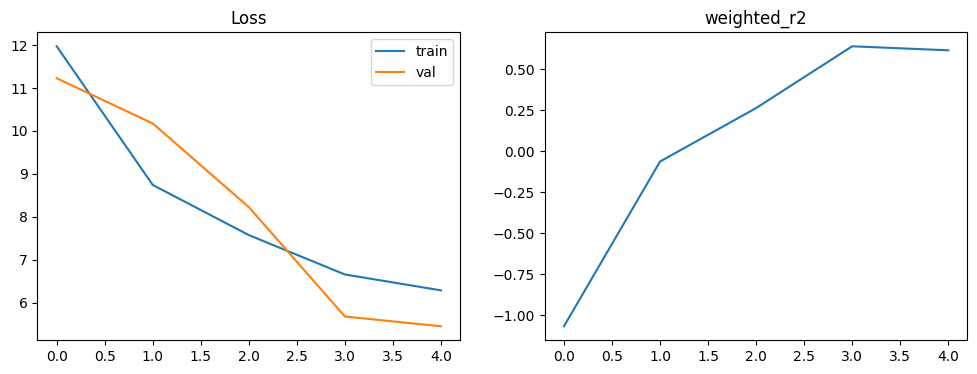

### fold=1
dataset size: 285
dataset size: 72
Epoch [0/5]: Train Loss: 11.3225, Val Loss: 10.9407, weighted_r2: -0.3747, lr: 0.001

Training completed. Best weighted_r2: 0.4283


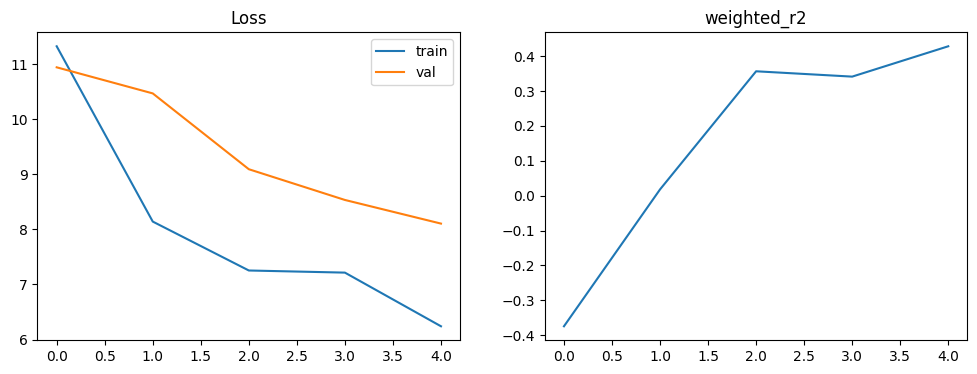

Avg CV: 0.5340719014406204


In [65]:
NFOLD = 2
all_best_score = []

for i in range(NFOLD):
    print(f'### fold={i}')
    history, best_score = train_fold(agg_train_df, fold=i)
    all_best_score.append(best_score)
    history = pd.DataFrame(history)

    history.to_json(
        f'{OUTPUT_DIR}/history_fold{i}.jsonl',
        orient='records',
        lines=True,
        force_ascii=False,
    )

    # plot
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.title('Loss')
    plt.plot(history.train_loss, label='train')
    plt.plot(history.val_loss, label='val')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title('weighted_r2')
    plt.plot(history.weighted_r2)
    plt.show()

print('Avg CV:', np.mean(all_best_score))

# Inference

In [74]:
SAVED_MODELS = './trained_models/'
def predict(model, dataloader, device):
    model.to(device)
    model.eval()

    all_outputs = []
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
    
            outputs = model(images)
            all_outputs.append(outputs.detach().cpu())
    
    outputs = torch.cat(all_outputs).numpy()
    return outputs

def kfold_predict(dataloader):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    
    all_preds = []
    for model_file in Path(SAVED_MODELS).glob('*.pth'):
        model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=3)
        model.load_state_dict(torch.load(model_file))

        preds = predict(model, dataloader, device)
        all_preds.append(preds)

    avg_preds = np.mean(all_preds, axis=0)
    return avg_preds

In [75]:
test_df = pd.read_csv(DATA_ROOT + 'test.csv')

test_df['target'] = 0.0
test_df[['sample_id_prefix', 'sample_id_suffix']] = test_df.sample_id.str.split('__', expand=True)

In [76]:
cols = ['sample_id_prefix', 'image_path']
agg_test_df = test_df.groupby(cols).apply(lambda df: df.set_index('target_name').target)
agg_test_df.reset_index(inplace=True)
agg_test_df.columns.name = None

agg_test_df['image'] = agg_test_df.image_path.progress_apply(
    lambda path: Image.open(DATA_ROOT + path).convert('RGB')
)

agg_test_df.head()

/var/folders/x3/7k5s3h7d4mdb27xn_jc79y_40000gn/T/ipykernel_36587/2521428785.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_test_df = test_df.groupby(cols).apply(lambda df: df.set_index('target_name').target)


  0%|          | 0/1 [00:00<?, ?it/s]

,sample_id_prefix,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,image
0,ID1001187975,test/ID1001187975.jpg,0.0,0.0,0.0,0.0,0.0,<PIL.Image.Image image mode=RGB size=2000x1000...


In [78]:
test_loader = create_dataloader(agg_test_df, TARGET_IMAGE_SIZE, 32, shuffle=False, aug=False)

dataset size: 1


In [79]:
preds = kfold_predict(test_loader)
agg_test_df[['Dry_Green_g', 'Dry_Clover_g', 'Dry_Dead_g']] = preds
agg_test_df['GDM_g'] = agg_test_df.Dry_Green_g + agg_test_df.Dry_Clover_g
agg_test_df['Dry_Total_g'] = agg_test_df.GDM_g + agg_test_df.Dry_Dead_g

agg_test_df.head()

,sample_id_prefix,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,image
0,ID1001187975,test/ID1001187975.jpg,3.809623,19.5233,25.01577,48.348694,28.825394,<PIL.Image.Image image mode=RGB size=2000x1000...


In [80]:
cols = ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']
sub_df = agg_test_df.set_index('sample_id_prefix')[cols].stack()
sub_df = sub_df.reset_index()
sub_df.columns = ['sample_id_prefix', 'target_name', 'target']

sub_df['sample_id'] = sub_df.sample_id_prefix + '__' + sub_df.target_name

cols = ['sample_id', 'target']
sub_df[cols].to_csv('submission.csv', index=False)  

In [85]:
print(len(agg_test_df))

1


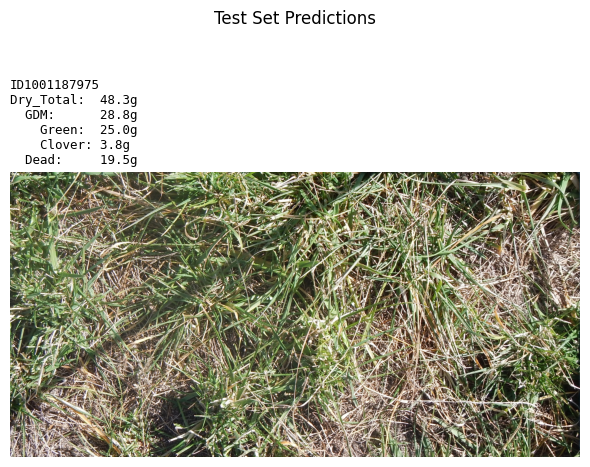

In [86]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
row = agg_test_df.iloc[0]

axes.imshow(row['image'])
axes.axis('off')

title = (
    f"{row['sample_id_prefix']}\n"
    f"Dry_Total:  {row['Dry_Total_g']:.1f}g\n"
    f"  GDM:      {row['GDM_g']:.1f}g\n"
    f"    Green:  {row['Dry_Green_g']:.1f}g\n"
    f"    Clover: {row['Dry_Clover_g']:.1f}g\n"
    f"  Dead:     {row['Dry_Dead_g']:.1f}g"
)
axes.set_title(title, fontsize=9, family='monospace', loc='left')

plt.suptitle('Test Set Predictions', fontsize=12)
plt.tight_layout()
plt.show()


In [87]:
!head submission.csv

sample_id,target
ID1001187975__Dry_Clover_g,3.8096228
ID1001187975__Dry_Dead_g,19.5233
ID1001187975__Dry_Green_g,25.01577
ID1001187975__Dry_Total_g,48.348694
ID1001187975__GDM_g,28.825394


dataset size: 72


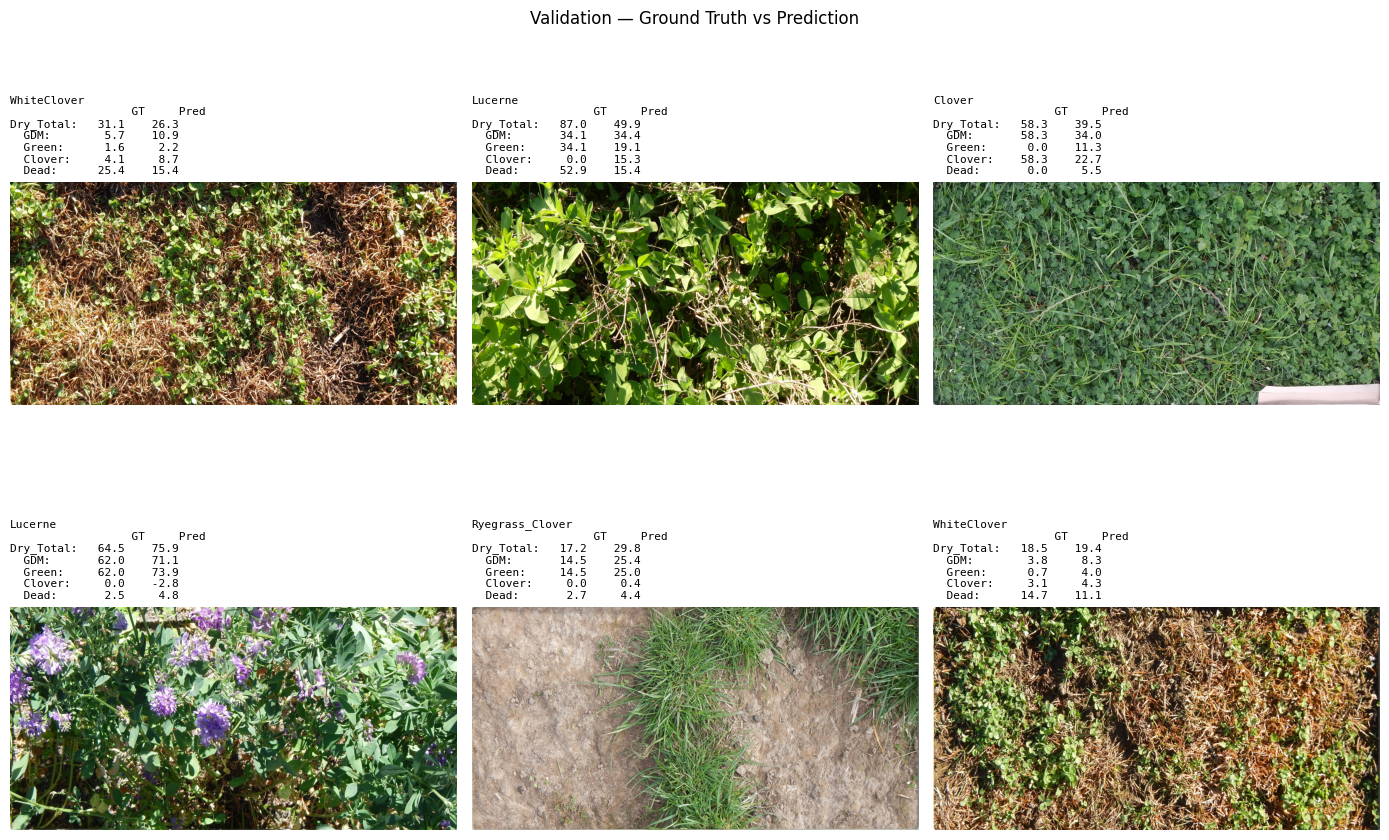

In [82]:
# Get predictions on training data (use fold 0 val set as example)
val_df = agg_train_df[agg_train_df.fold == 0].copy()
val_loader = create_dataloader(val_df, TARGET_IMAGE_SIZE, 32, shuffle=False, aug=False)
val_preds = kfold_predict(val_loader)

target_cols = ['Dry_Green_g', 'Dry_Clover_g', 'Dry_Dead_g']
pred_df = val_df.copy().reset_index(drop=True)
pred_df[['pred_Green', 'pred_Clover', 'pred_Dead']] = val_preds
pred_df['pred_GDM'] = pred_df.pred_Green + pred_df.pred_Clover
pred_df['pred_Total'] = pred_df.pred_GDM + pred_df.pred_Dead

n = 6
samples = pred_df.sample(n)

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    ax.imshow(row['image'])
    ax.axis('off')

    title = (
        f"{row['Species']}\n"
        f"{'':12s} {'GT':>7s}  {'Pred':>7s}\n"
        f"Dry_Total: {row['Dry_Total_g']:>6.1f}  {row['pred_Total']:>6.1f}\n"
        f"  GDM:     {row['GDM_g']:>6.1f}  {row['pred_GDM']:>6.1f}\n"
        f"  Green:   {row['Dry_Green_g']:>6.1f}  {row['pred_Green']:>6.1f}\n"
        f"  Clover:  {row['Dry_Clover_g']:>6.1f}  {row['pred_Clover']:>6.1f}\n"
        f"  Dead:    {row['Dry_Dead_g']:>6.1f}  {row['pred_Dead']:>6.1f}"
    )
    ax.set_title(title, fontsize=8, family='monospace', loc='left')

plt.suptitle('Validation — Ground Truth vs Prediction', fontsize=12)
plt.tight_layout()
plt.show()

In [1]:
!kaggle competitions submit -c csiro-biomass -f submission.csv -k sansethisak/<NOTEBOOK> -v <VERSION> -m "Message"

zsh:1: no such file or directory: NOTEBOOK
